# Análisis de Indicadores de Hospitalización REM20

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from scipy import stats

# Estilo general
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)

# Carga del dataset
df = pd.read_csv(
    r"C:/Users/bravo/OneDrive/Escritorio/Analisis de datos/proyecto_analisis_datos/data/indicadores_rem20_20260225.csv",
    sep=";"
)

# Limpiar espacios en AREA_FUNCIONAL
df['AREA_FUNCIONAL'] = df['AREA_FUNCIONAL'].str.strip()

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Períodos: {df['PERIODO'].min()} – {df['PERIODO'].max()}")
df.head()

Dataset cargado: 159,788 filas | 20 columnas
Períodos: 2014 – 2025


,PERIODO,TIPO_PERTENENCIA,COD_SSS,GLOSA_SSS,CODIGO_ESTABLECIMIENTO,ESTABLECIMIENTO,COD_AREA_FUNCIONAL,AREA_FUNCIONAL,MES,DIAS_CAMAS_OCUPADAS,DIAS_CAMAS_DISPONIBLES,DIAS_ESTADA,NUMERO_EGRESOS,EGRESOS_FALLECIDOS,TRASLADOS,INDICE_OCUPACIONAL,PROMEDIO_CAMAS_DISPONIBLE,PROMEDIO_DIAS_ESTADA,LETALIDAD,INDICE_ROTACION
0,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,1,139,186,115,9,7,12,74.73,6.0,12.78,77.78,1.50
1,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,2,103,168,164,7,4,21,61.31,6.0,23.43,57.14,1.17
2,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,3,117,186,98,15,9,12,62.90,6.0,6.53,60.00,2.50
3,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,4,126,180,114,7,5,17,70.00,6.0,16.29,71.43,1.17
4,2014,1,1,Arica,101100,Hospital Dr Juan Noé Crevanni (Arica),405,Área Cuidados Intensivos Adultos,5,141,186,165,11,7,19,75.81,6.0,15.00,63.64,1.83


In [20]:
# Detección de problemas en el dataset
def detectar_problemas_datos(df):
    problemas = []
    for col in df.columns:
        serie = df[col]
        nulos = serie.isna().sum()
        negativos = 0
        if pd.api.types.is_numeric_dtype(serie):
            negativos = (serie < 0).sum()
        fuera_rango = 0
        if col == "MES":
            fuera_rango = ((serie < 1) | (serie > 12)).sum()
        elif col == "PERIODO":
            fuera_rango = ((serie < 2000) | (serie > 2030)).sum()
        elif col in ["INDICE_OCUPACIONAL", "LETALIDAD"]:
            fuera_rango = ((serie < 0) | (serie > 100)).sum()
        elif col in [
            "DIAS_CAMAS_OCUPADAS", "DIAS_CAMAS_DISPONIBLES", "DIAS_ESTADA",
            "NUMERO_EGRESOS", "EGRESOS_FALLECIDOS", "TRASLADOS",
            "PROMEDIO_CAMAS_DISPONIBLE", "PROMEDIO_DIAS_ESTADA", "INDICE_ROTACION"
        ]:
            fuera_rango = (serie < 0).sum()
        problemas.append({"columna": col, "nulos": nulos, "negativos": negativos, "fuera_de_rango": fuera_rango})
    return pd.DataFrame(problemas)

reporte = detectar_problemas_datos(df)
print(reporte)
print(f"\nMin INDICE_OCUPACIONAL: {df['INDICE_OCUPACIONAL'].min():.2f}")
print(f"Max INDICE_OCUPACIONAL: {df['INDICE_OCUPACIONAL'].max():.2f}")

                      columna  nulos  negativos  fuera_de_rango
0                     PERIODO      0          0               0
1            TIPO_PERTENENCIA      0          0               0
2                     COD_SSS      0          0               0
3                   GLOSA_SSS      0          0               0
4      CODIGO_ESTABLECIMIENTO      0          0               0
5             ESTABLECIMIENTO      0          0               0
6          COD_AREA_FUNCIONAL      0          0               0
7              AREA_FUNCIONAL      0          0               0
8                         MES      0          0               0
9         DIAS_CAMAS_OCUPADAS      0          0               0
10     DIAS_CAMAS_DISPONIBLES      0          0               0
11                DIAS_ESTADA      0          0               0
12             NUMERO_EGRESOS      0          0               0
13         EGRESOS_FALLECIDOS      0          0               0
14                  TRASLADOS      0    

## Pregunta 1
### ¿Cómo han evolucionado los patrones de hospitalización en los últimos años?

**Variables:** `NUMERO_EGRESOS`, `DIAS_CAMAS_OCUPADAS`, `DIAS_CAMAS_DISPONIBLES`, `INDICE_OCUPACIONAL` + `PERIODO` (eje temporal obligatorio)

In [21]:
# Agregación anual: sumar valores absolutos y promediar índice
p1 = df.groupby('PERIODO').agg(
    NUMERO_EGRESOS=('NUMERO_EGRESOS', 'sum'),
    DIAS_CAMAS_OCUPADAS=('DIAS_CAMAS_OCUPADAS', 'sum'),
    DIAS_CAMAS_DISPONIBLES=('DIAS_CAMAS_DISPONIBLES', 'sum'),
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean')
).reset_index()

print(p1.to_string(index=False))

 PERIODO  NUMERO_EGRESOS  DIAS_CAMAS_OCUPADAS  DIAS_CAMAS_DISPONIBLES  INDICE_OCUPACIONAL
    2014         1080298              7162470                 9158150           64.421340
    2015         1070466              7250906                 9233892           64.846314
    2016         1034700              7256004                 9272334           63.690429
    2017         1041327              7398103                 9353661           63.744643
    2018         1061028              7512701                 9408215           65.776845
    2019         1065092              7577071                 9443021           66.077504
    2020          836287              6456741                 9493833           54.896112
    2021          861500              7133962                 9450490           59.433790
    2022          927210              7315886                 9330209           64.030589
    2023          994127              7637838                 9449474           66.882792
    2024  

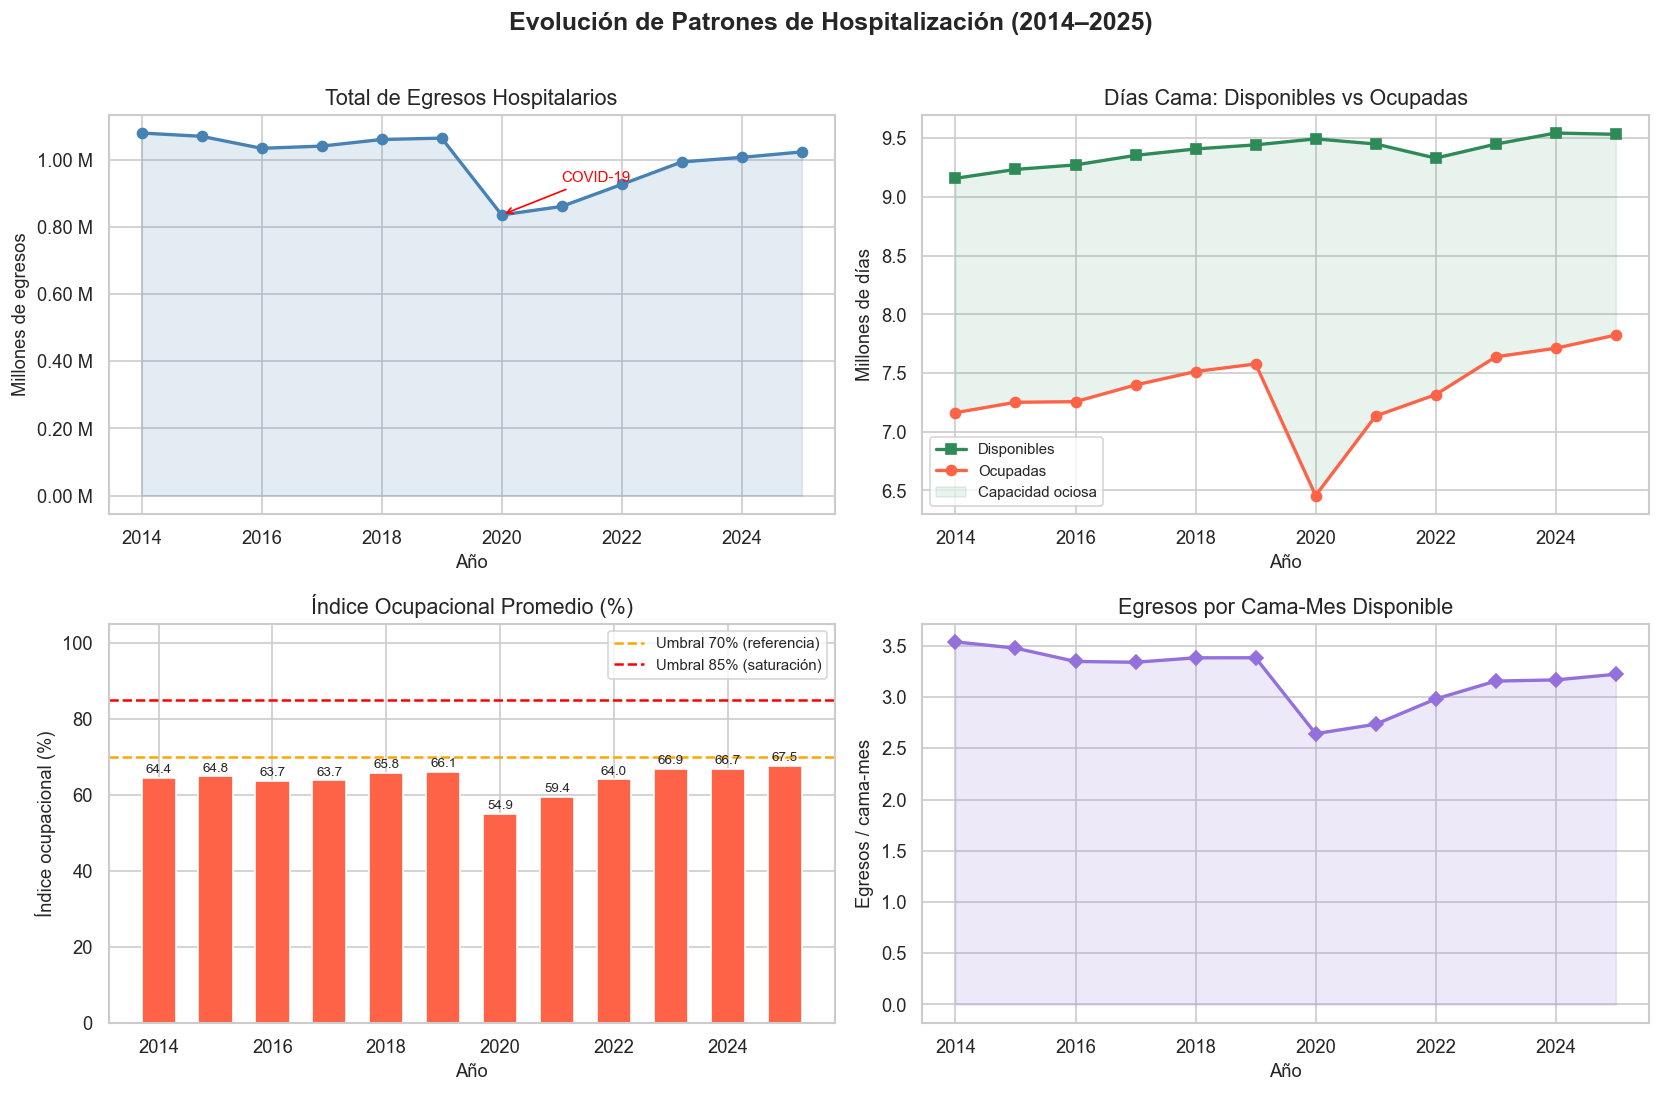

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Evolución de Patrones de Hospitalización (2014–2025)', fontsize=15, fontweight='bold', y=1.01)

years = p1['PERIODO']

# --- Egresos totales ---
ax = axes[0, 0]
ax.plot(years, p1['NUMERO_EGRESOS'] / 1e6, marker='o', linewidth=2, color='steelblue')
ax.fill_between(years, p1['NUMERO_EGRESOS'] / 1e6, alpha=0.15, color='steelblue')
ax.set_title('Total de Egresos Hospitalarios')
ax.set_ylabel('Millones de egresos')
ax.set_xlabel('Año')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f M'))

# Anotación caída COVID
idx_2020 = p1[p1['PERIODO'] == 2020].index[0] if 2020 in p1['PERIODO'].values else None
if idx_2020 is not None:
    ax.annotate('COVID-19', xy=(2020, p1.loc[idx_2020, 'NUMERO_EGRESOS'] / 1e6),
                xytext=(2021, p1.loc[idx_2020, 'NUMERO_EGRESOS'] / 1e6 + 0.1),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# --- Días cama ocupadas vs disponibles ---
ax = axes[0, 1]
ax.plot(years, p1['DIAS_CAMAS_DISPONIBLES'] / 1e6, marker='s', linewidth=2, label='Disponibles', color='seagreen')
ax.plot(years, p1['DIAS_CAMAS_OCUPADAS'] / 1e6, marker='o', linewidth=2, label='Ocupadas', color='tomato')
ax.fill_between(years,
                p1['DIAS_CAMAS_OCUPADAS'] / 1e6,
                p1['DIAS_CAMAS_DISPONIBLES'] / 1e6,
                alpha=0.1, color='seagreen', label='Capacidad ociosa')
ax.set_title('Días Cama: Disponibles vs Ocupadas')
ax.set_ylabel('Millones de días')
ax.set_xlabel('Año')
ax.legend(fontsize=9)

# --- Índice ocupacional promedio ---
ax = axes[1, 0]
colors_bar = ['tomato' if v < 70 else 'steelblue' for v in p1['INDICE_OCUPACIONAL']]
bars = ax.bar(years, p1['INDICE_OCUPACIONAL'], color=colors_bar, edgecolor='white', width=0.6)
ax.axhline(70, color='orange', linestyle='--', linewidth=1.5, label='Umbral 70% (referencia)')
ax.axhline(85, color='red', linestyle='--', linewidth=1.5, label='Umbral 85% (saturación)')
ax.set_title('Índice Ocupacional Promedio (%)')
ax.set_ylabel('Índice ocupacional (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

# --- Tasa de egresos por cama disponible (derivado: eficiencia bruta) ---
p1['EGRESOS_POR_CAMA'] = p1['NUMERO_EGRESOS'] / (p1['DIAS_CAMAS_DISPONIBLES'] / 30)
ax = axes[1, 1]
ax.plot(years, p1['EGRESOS_POR_CAMA'], marker='D', linewidth=2, color='mediumpurple')
ax.fill_between(years, p1['EGRESOS_POR_CAMA'], alpha=0.15, color='mediumpurple')
ax.set_title('Egresos por Cama-Mes Disponible')
ax.set_ylabel('Egresos / cama-mes')
ax.set_xlabel('Año')

plt.tight_layout()
plt.show()

In [5]:
# Variación porcentual 2014 → último año disponible
ultimo = p1.iloc[-1]
primero = p1.iloc[0]

for col in ['NUMERO_EGRESOS', 'DIAS_CAMAS_OCUPADAS', 'DIAS_CAMAS_DISPONIBLES', 'INDICE_OCUPACIONAL']:
    var = ((ultimo[col] - primero[col]) / primero[col]) * 100
    print(f"{col}: {primero[col]:,.1f} → {ultimo[col]:,.1f}  ({var:+.1f}%)")

# Año con menor índice ocupacional
min_occ = p1.loc[p1['INDICE_OCUPACIONAL'].idxmin()]
print(f"\nAño con menor índice ocupacional: {int(min_occ['PERIODO'])} ({min_occ['INDICE_OCUPACIONAL']:.1f}%)")

NUMERO_EGRESOS: 1,080,298.0 → 1,024,018.0  (-5.2%)
DIAS_CAMAS_OCUPADAS: 7,162,470.0 → 7,823,327.0  (+9.2%)
DIAS_CAMAS_DISPONIBLES: 9,158,150.0 → 9,532,838.0  (+4.1%)
INDICE_OCUPACIONAL: 64.4 → 67.5  (+4.8%)

Año con menor índice ocupacional: 2020 (54.9%)


## Pregunta 2
### ¿Existen cambios temporales en la complejidad clínica de las hospitalizaciones?

**Variables:** `PROMEDIO_DIAS_ESTADA`, `LETALIDAD`, `INDICE_ROTACION`, `AREA_FUNCIONAL` + `PERIODO` (agregado para el eje temporal)

In [6]:
# Agregación anual de indicadores de complejidad clínica
p2_anual = df.groupby('PERIODO').agg(
    PROMEDIO_DIAS_ESTADA=('PROMEDIO_DIAS_ESTADA', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

# Las áreas de alta complejidad son UCI adulto, UCI pediátrico e intermedios
AREAS_ALTA_COMPLEJIDAD = [
    'Área Cuidados Intensivos Adultos',
    'Área Cuidados Intensivos Pediátricos',
    'Área Cuidados Intermedios Adultos',
    'Área Cuidados Intermedios Pediátricos',
    'Área Neonatología Cuidados Intensivos'
]
AREAS_BAJA_COMPLEJIDAD = [
    'Área Médica Adulto Cuidados Básicos',
    'Área Médico-Quirúrgico Cuidados Básicos',
    'Área Obstetricia'
]

# Comparación por tipo de complejidad en el tiempo
df['COMPLEJIDAD'] = np.where(
    df['AREA_FUNCIONAL'].isin(AREAS_ALTA_COMPLEJIDAD), 'Alta complejidad',
    np.where(df['AREA_FUNCIONAL'].isin(AREAS_BAJA_COMPLEJIDAD), 'Baja complejidad', 'Media complejidad')
)

p2_comp = df.groupby(['PERIODO', 'COMPLEJIDAD']).agg(
    PROMEDIO_DIAS_ESTADA=('PROMEDIO_DIAS_ESTADA', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

print(p2_anual.round(2).to_string(index=False))

 PERIODO  PROMEDIO_DIAS_ESTADA  LETALIDAD  INDICE_ROTACION
    2014                 16.94       7.62             3.47
    2015                 18.23       7.64             3.57
    2016                 17.75       7.76             2.97
    2017                 17.66       7.85             2.94
    2018                 18.86       7.78             3.03
    2019                 20.23       7.85             2.99
    2020                 18.37       8.02             2.25
    2021                 19.98       7.91             2.41
    2022                 19.61       7.77             2.64
    2023                 19.51       7.59             2.78
    2024                 19.44       7.49             2.71
    2025                 21.21       7.53             2.78


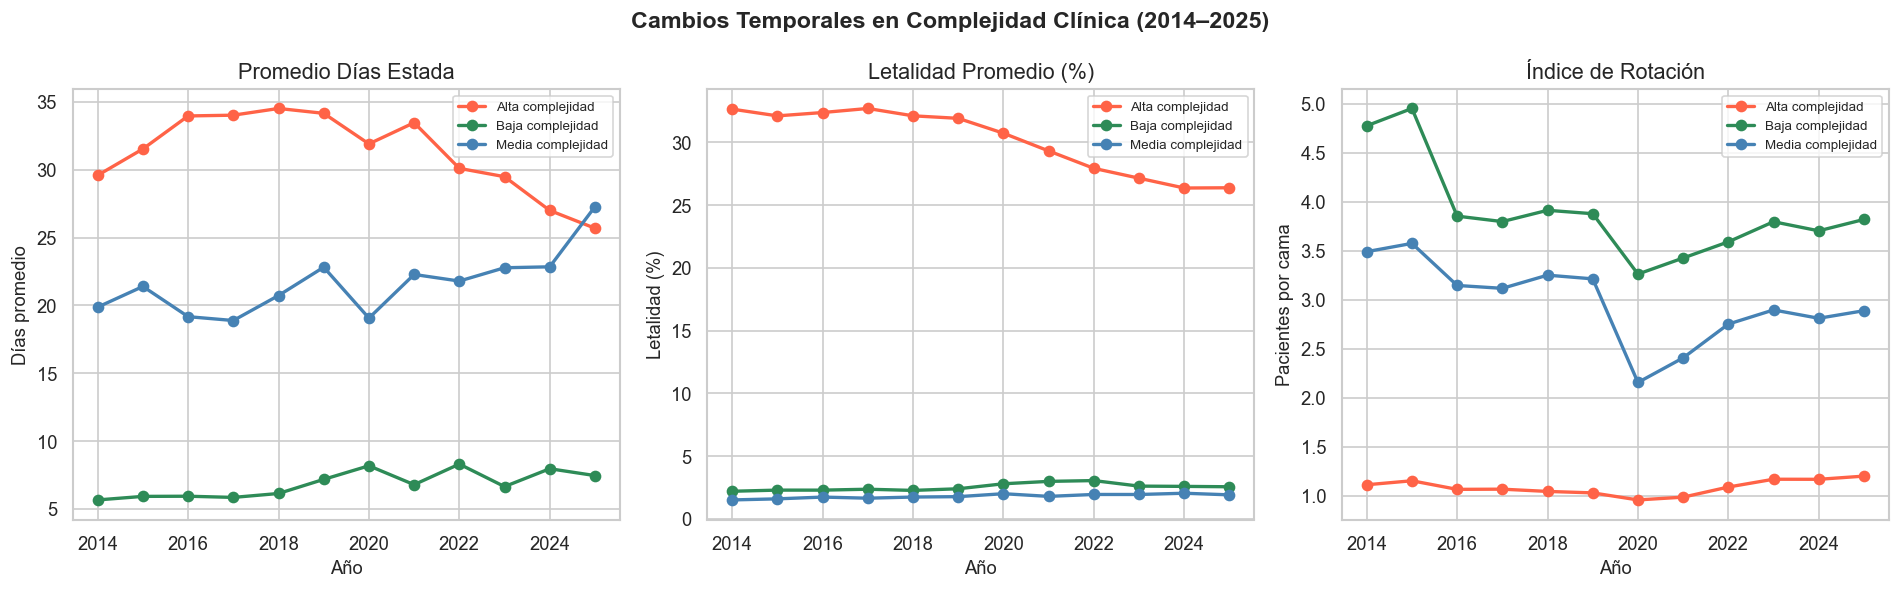

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cambios Temporales en Complejidad Clínica (2014–2025)', fontsize=14, fontweight='bold')

palette = {'Alta complejidad': 'tomato', 'Media complejidad': 'steelblue', 'Baja complejidad': 'seagreen'}

for comp, grp in p2_comp.groupby('COMPLEJIDAD'):
    grp = grp.sort_values('PERIODO')
    axes[0].plot(grp['PERIODO'], grp['PROMEDIO_DIAS_ESTADA'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)
    axes[1].plot(grp['PERIODO'], grp['LETALIDAD'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)
    axes[2].plot(grp['PERIODO'], grp['INDICE_ROTACION'], marker='o', label=comp,
                 color=palette[comp], linewidth=2)

axes[0].set_title('Promedio Días Estada')
axes[0].set_ylabel('Días promedio')
axes[0].set_xlabel('Año')
axes[0].legend(fontsize=8)

axes[1].set_title('Letalidad Promedio (%)')
axes[1].set_ylabel('Letalidad (%)')
axes[1].set_xlabel('Año')
axes[1].legend(fontsize=8)

axes[2].set_title('Índice de Rotación')
axes[2].set_ylabel('Pacientes por cama')
axes[2].set_xlabel('Año')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

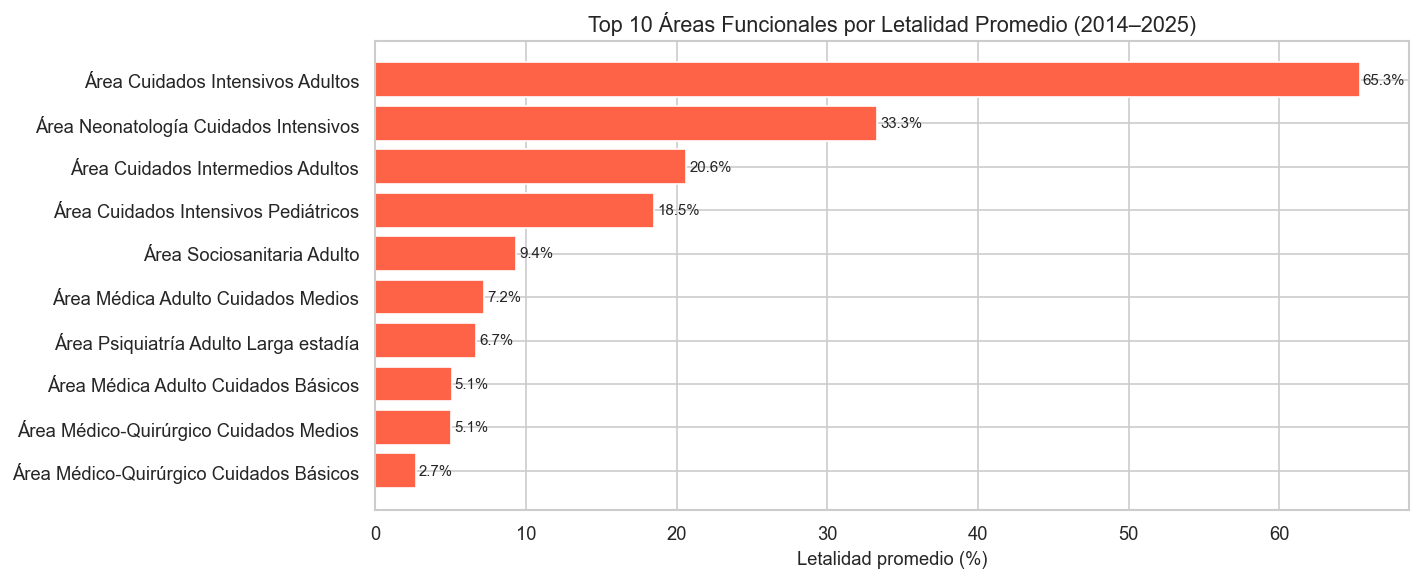

In [8]:
# Top 10 áreas funcionales con mayor letalidad promedio histórica
top_letalidad = (
    df.groupby('AREA_FUNCIONAL')['LETALIDAD']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_letalidad['AREA_FUNCIONAL'], top_letalidad['LETALIDAD'],
               color='tomato', edgecolor='white')
ax.set_xlabel('Letalidad promedio (%)')
ax.set_title('Top 10 Áreas Funcionales por Letalidad Promedio (2014–2025)')
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Pregunta 3
### ¿Cómo varía la duración promedio de la hospitalización entre áreas funcionales y en el tiempo?

**Variables:** `PROMEDIO_DIAS_ESTADA`, `AREA_FUNCIONAL`, `PERIODO`

In [9]:
# Promedio de días estada por área funcional y año
p3 = df.groupby(['AREA_FUNCIONAL', 'PERIODO'])['PROMEDIO_DIAS_ESTADA'].mean().reset_index()

# Tabla pivot para heatmap
p3_pivot = p3.pivot(index='AREA_FUNCIONAL', columns='PERIODO', values='PROMEDIO_DIAS_ESTADA')
p3_pivot = p3_pivot.sort_values(by=p3_pivot.columns[-1], ascending=False)

print("Áreas con mayor promedio de días de estada (último año):")
print(p3_pivot.iloc[:, -1].sort_values(ascending=False).head(10).round(1))

Áreas con mayor promedio de días de estada (último año):
AREA_FUNCIONAL
Área Psiquiatría Adulto Larga estadía                                   879.2
Área Psiquiatría Forense Adulto tratamiento                             726.3
Área Psiquiatría Forense Adulto evaluación e inicio tto.                256.6
Área Psiquiatría Adulto Mediana estadía                                 194.3
Área Sociosanitaria Adulto                                              109.0
Área Psiquiatría Infanto-adolescente mediana estadía                     69.5
Área Neonatología Cuidados Intensivos                                    46.8
Área Cuidados Intensivos Pediátricos                                     32.9
Área Psiquiatría Forense Infanto Adolescente tratamiento                 32.0
Área de Hospitalización de Cuidados Intensivos en Psiquiatría Adulto     29.0
Name: 2025, dtype: float64


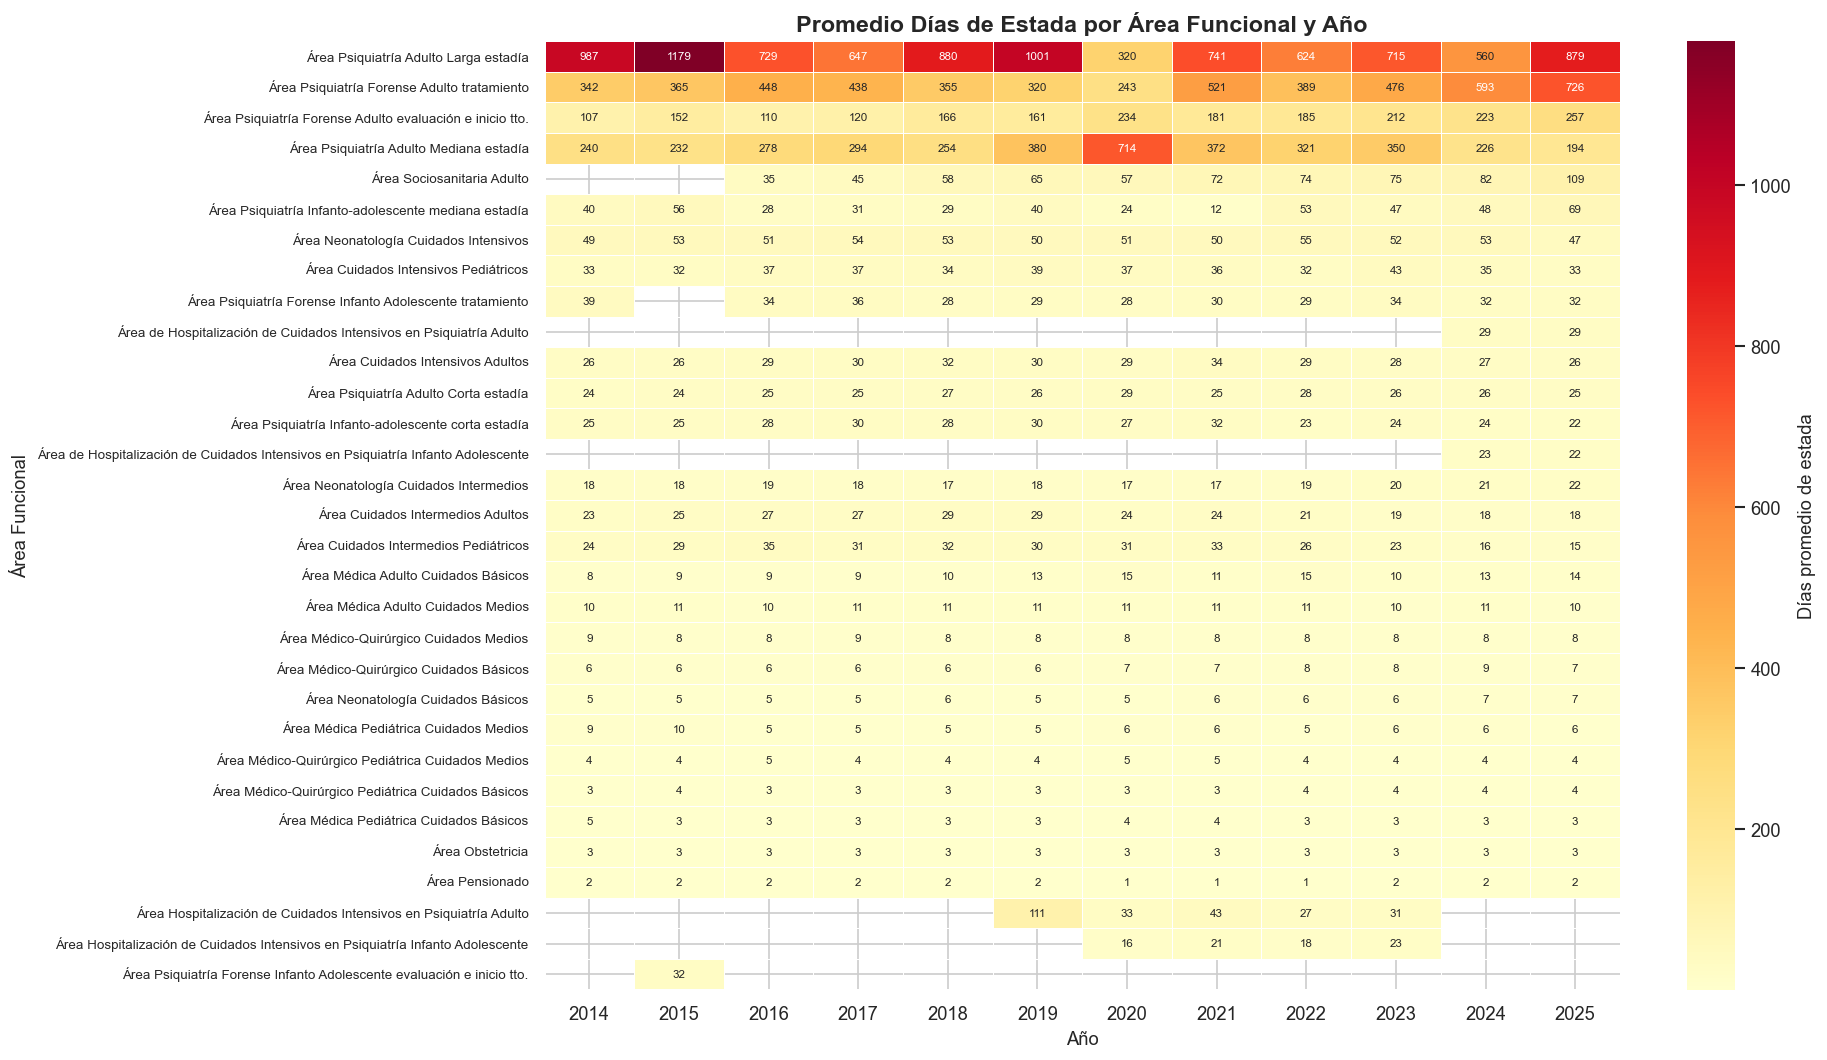

In [10]:
# Heatmap: días estada por área funcional y año
fig, ax = plt.subplots(figsize=(16, 9))

# Usar escala logarítmica para suavizar outliers de psiquiatría
sns.heatmap(
    p3_pivot,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Días promedio de estada'},
    ax=ax
)
ax.set_title('Promedio Días de Estada por Área Funcional y Año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Área Funcional')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

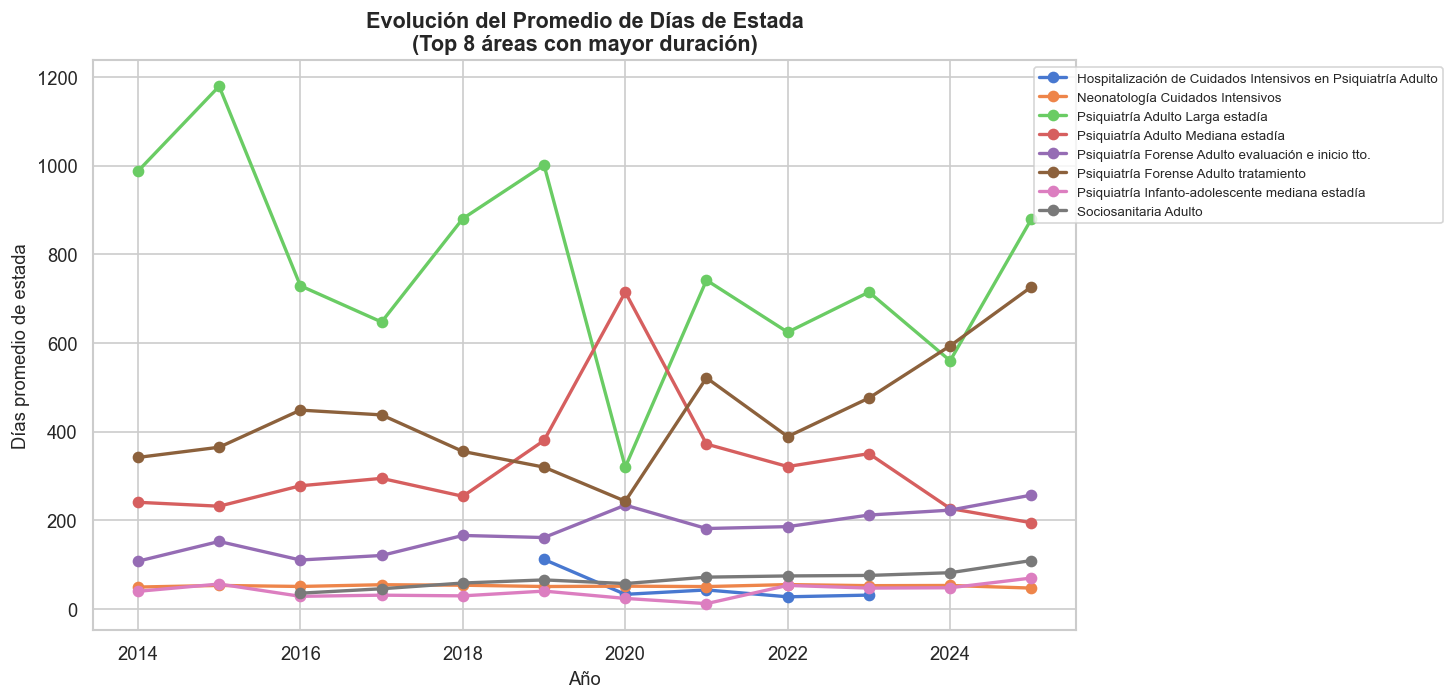

In [11]:
# Evolución temporal para las 8 áreas con mayor promedio de días estada
top8_areas = (
    df.groupby('AREA_FUNCIONAL')['PROMEDIO_DIAS_ESTADA']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

p3_top = p3[p3['AREA_FUNCIONAL'].isin(top8_areas)]

fig, ax = plt.subplots(figsize=(13, 6))
for area, grp in p3_top.groupby('AREA_FUNCIONAL'):
    grp = grp.sort_values('PERIODO')
    # Nombre corto para la leyenda
    label = area.replace('Área ', '').strip()
    ax.plot(grp['PERIODO'], grp['PROMEDIO_DIAS_ESTADA'], marker='o', linewidth=2, label=label)

ax.set_title('Evolución del Promedio de Días de Estada\n(Top 8 áreas con mayor duración)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Días promedio de estada')
ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.38, 1))
plt.tight_layout()
plt.show()

C:\Users\bravo\AppData\Local\Temp\ipykernel_7476\278923970.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


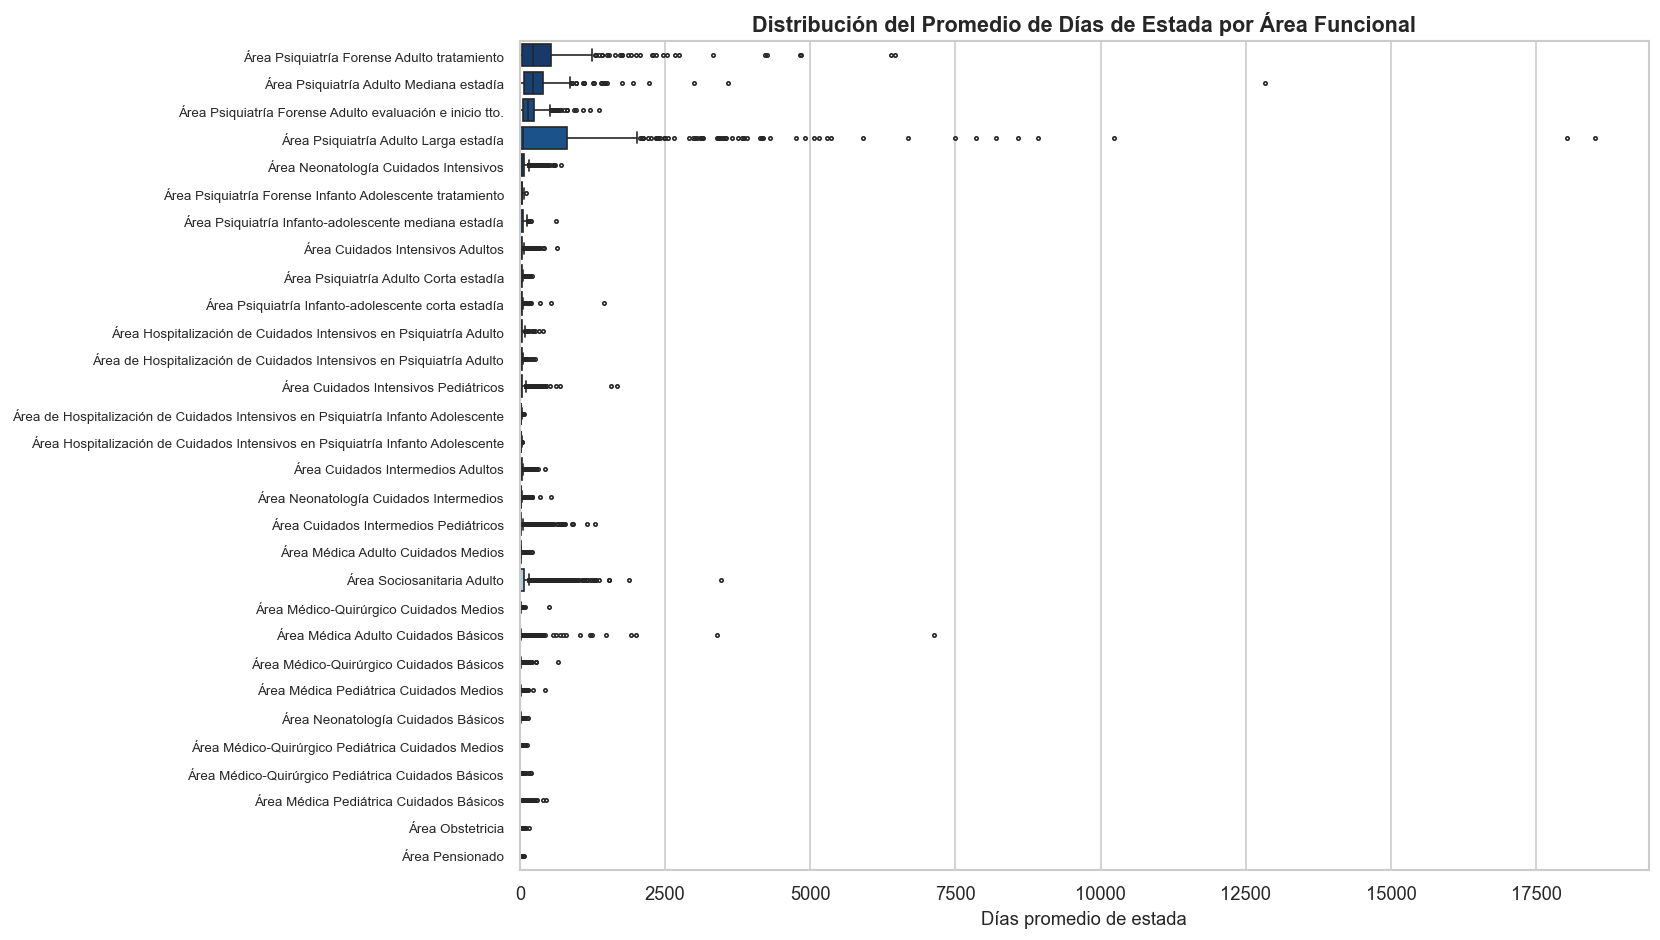

In [12]:
# Distribución general de días estada por área funcional (boxplot)
# Filtrar áreas con al menos 100 registros para que sea representativo
areas_validas = df['AREA_FUNCIONAL'].value_counts()[lambda x: x >= 100].index
df_box = df[df['AREA_FUNCIONAL'].isin(areas_validas)]

# Calcular mediana por área para ordenar
orden = (
    df_box.groupby('AREA_FUNCIONAL')['PROMEDIO_DIAS_ESTADA']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=df_box,
    x='PROMEDIO_DIAS_ESTADA',
    y='AREA_FUNCIONAL',
    order=orden,
    palette='Blues_r',
    fliersize=2,
    ax=ax
)
ax.set_title('Distribución del Promedio de Días de Estada por Área Funcional', fontweight='bold')
ax.set_xlabel('Días promedio de estada')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## Pregunta 4
### ¿Cómo ha variado la eficiencia en el uso de camas hospitalarias a lo largo del tiempo?

**Variables:** `PERIODO`, `INDICE_OCUPACIONAL`, `INDICE_ROTACION` + `AREA_FUNCIONAL` (para comparar UCI vs otras)

In [13]:
# Agregación anual general
p4_anual = df.groupby('PERIODO').agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

# Por área funcional y año (usar grupos de complejidad ya definidos)
p4_comp = df.groupby(['PERIODO', 'COMPLEJIDAD']).agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    INDICE_ROTACION=('INDICE_ROTACION', 'mean')
).reset_index()

print("Variación anual de índices de eficiencia:")
print(p4_anual.round(2).to_string(index=False))

Variación anual de índices de eficiencia:
 PERIODO  INDICE_OCUPACIONAL  INDICE_ROTACION
    2014               64.42             3.47
    2015               64.85             3.57
    2016               63.69             2.97
    2017               63.74             2.94
    2018               65.78             3.03
    2019               66.08             2.99
    2020               54.90             2.25
    2021               59.43             2.41
    2022               64.03             2.64
    2023               66.88             2.78
    2024               66.74             2.71
    2025               67.54             2.78


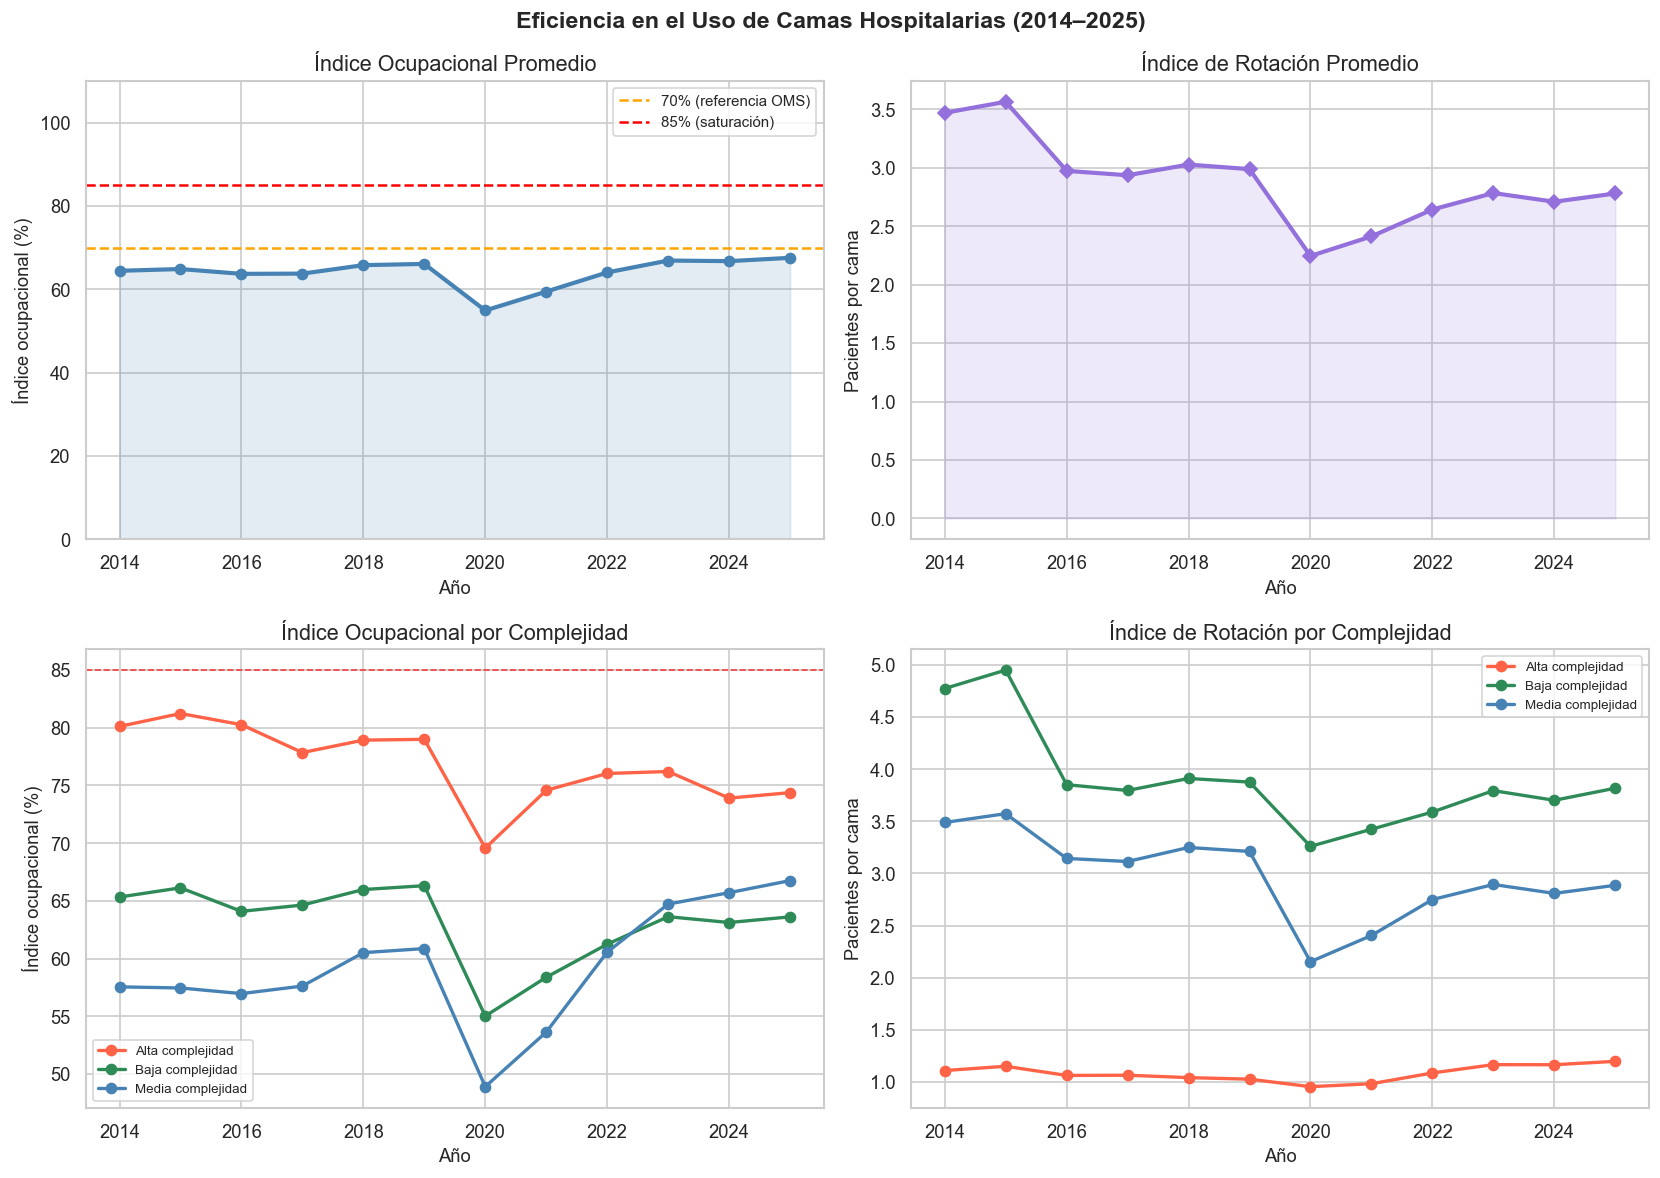

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eficiencia en el Uso de Camas Hospitalarias (2014–2025)', fontsize=14, fontweight='bold')

years = p4_anual['PERIODO']

# --- Índice ocupacional general ---
ax = axes[0, 0]
ax.plot(years, p4_anual['INDICE_OCUPACIONAL'], marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(years, p4_anual['INDICE_OCUPACIONAL'], alpha=0.15, color='steelblue')
ax.axhline(70, color='orange', linestyle='--', linewidth=1.5, label='70% (referencia OMS)')
ax.axhline(85, color='red', linestyle='--', linewidth=1.5, label='85% (saturación)')
ax.set_title('Índice Ocupacional Promedio')
ax.set_ylabel('Índice ocupacional (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.set_ylim(0, 110)

# --- Índice rotación general ---
ax = axes[0, 1]
ax.plot(years, p4_anual['INDICE_ROTACION'], marker='D', linewidth=2.5, color='mediumpurple')
ax.fill_between(years, p4_anual['INDICE_ROTACION'], alpha=0.15, color='mediumpurple')
ax.set_title('Índice de Rotación Promedio')
ax.set_ylabel('Pacientes por cama')
ax.set_xlabel('Año')

# --- Índice ocupacional por complejidad ---
ax = axes[1, 0]
for comp, grp in p4_comp.groupby('COMPLEJIDAD'):
    grp = grp.sort_values('PERIODO')
    ax.plot(grp['PERIODO'], grp['INDICE_OCUPACIONAL'], marker='o', label=comp,
            color=palette[comp], linewidth=2)
ax.axhline(85, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Índice Ocupacional por Complejidad')
ax.set_ylabel('Índice ocupacional (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

# --- Índice rotación por complejidad ---
ax = axes[1, 1]
for comp, grp in p4_comp.groupby('COMPLEJIDAD'):
    grp = grp.sort_values('PERIODO')
    ax.plot(grp['PERIODO'], grp['INDICE_ROTACION'], marker='o', label=comp,
            color=palette[comp], linewidth=2)
ax.set_title('Índice de Rotación por Complejidad')
ax.set_ylabel('Pacientes por cama')
ax.set_xlabel('Año')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

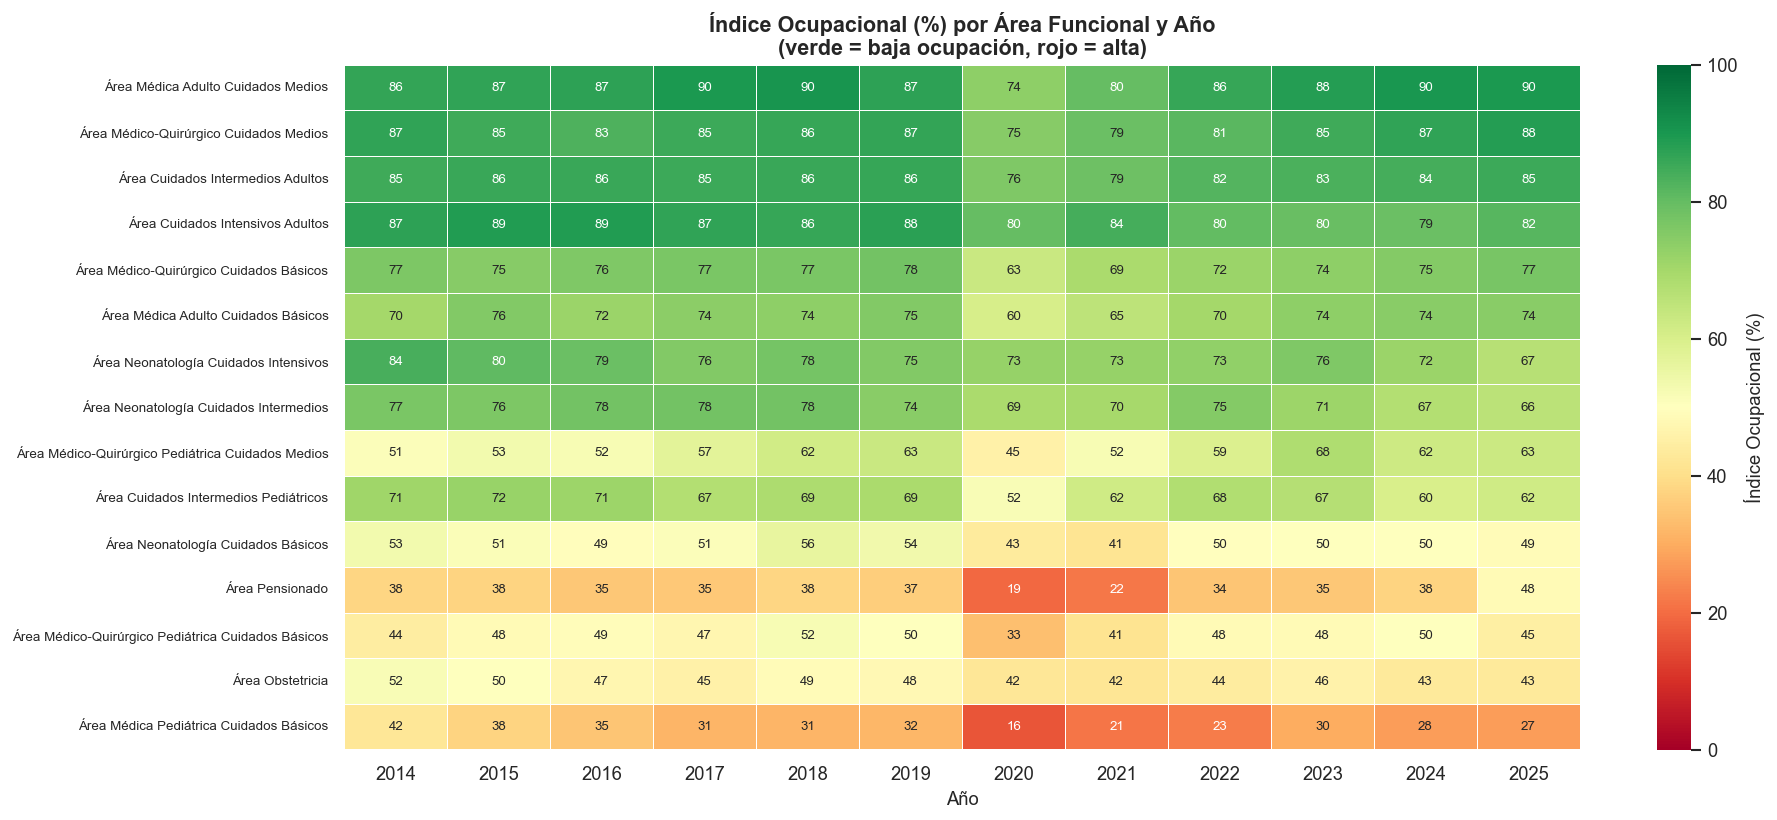

In [15]:
# Heatmap: índice ocupacional promedio por área funcional y año
# Filtrar para las áreas más relevantes (top 15 por número de registros)
top15_areas = df['AREA_FUNCIONAL'].value_counts().head(15).index.tolist()

p4_heat = (
    df[df['AREA_FUNCIONAL'].isin(top15_areas)]
    .groupby(['AREA_FUNCIONAL', 'PERIODO'])['INDICE_OCUPACIONAL']
    .mean()
    .reset_index()
    .pivot(index='AREA_FUNCIONAL', columns='PERIODO', values='INDICE_OCUPACIONAL')
)
p4_heat = p4_heat.sort_values(by=p4_heat.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    p4_heat,
    cmap='RdYlGn',
    linewidths=0.4,
    linecolor='white',
    annot=True,
    fmt='.0f',
    annot_kws={'size': 8},
    vmin=0, vmax=100,
    cbar_kws={'label': 'Índice Ocupacional (%)'},
    ax=ax
)
ax.set_title('Índice Ocupacional (%) por Área Funcional y Año\n(verde = baja ocupación, rojo = alta)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## Pregunta 5
### ¿Existe relación entre la ocupación hospitalaria y la letalidad de los pacientes?

**Variables:** `INDICE_OCUPACIONAL` (explicativa), `LETALIDAD` (respuesta) + `AREA_FUNCIONAL` (segmentación) + `PERIODO` (evolución)

In [16]:
# Correlación global
from scipy.stats import pearsonr, spearmanr

# Filtrar valores válidos (descartar ceros que pueden ser registros sin actividad)
df_p5 = df[(df['INDICE_OCUPACIONAL'] > 0) & (df['LETALIDAD'] >= 0)].copy()

r_pearson, p_pearson = pearsonr(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'])
r_spearman, p_spearman = spearmanr(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'])

print(f"Correlación de Pearson:  r = {r_pearson:.4f}  (p-value = {p_pearson:.4e})")
print(f"Correlación de Spearman: r = {r_spearman:.4f}  (p-value = {p_spearman:.4e})")
print()

# Correlación por complejidad
print("Correlación de Pearson por nivel de complejidad:")
for comp in df_p5['COMPLEJIDAD'].unique():
    sub = df_p5[df_p5['COMPLEJIDAD'] == comp]
    r, p = pearsonr(sub['INDICE_OCUPACIONAL'], sub['LETALIDAD'])
    print(f"  {comp}: r = {r:.4f}  (p = {p:.4e}, n = {len(sub):,})")

Correlación de Pearson:  r = 0.1897  (p-value = 0.0000e+00)
Correlación de Spearman: r = 0.3904  (p-value = 0.0000e+00)

Correlación de Pearson por nivel de complejidad:
  Alta complejidad: r = 0.2392  (p = 0.0000e+00, n = 32,089)
  Baja complejidad: r = 0.1667  (p = 1.9729e-291, n = 47,229)
  Media complejidad: r = 0.1411  (p = 1.8053e-320, n = 72,807)


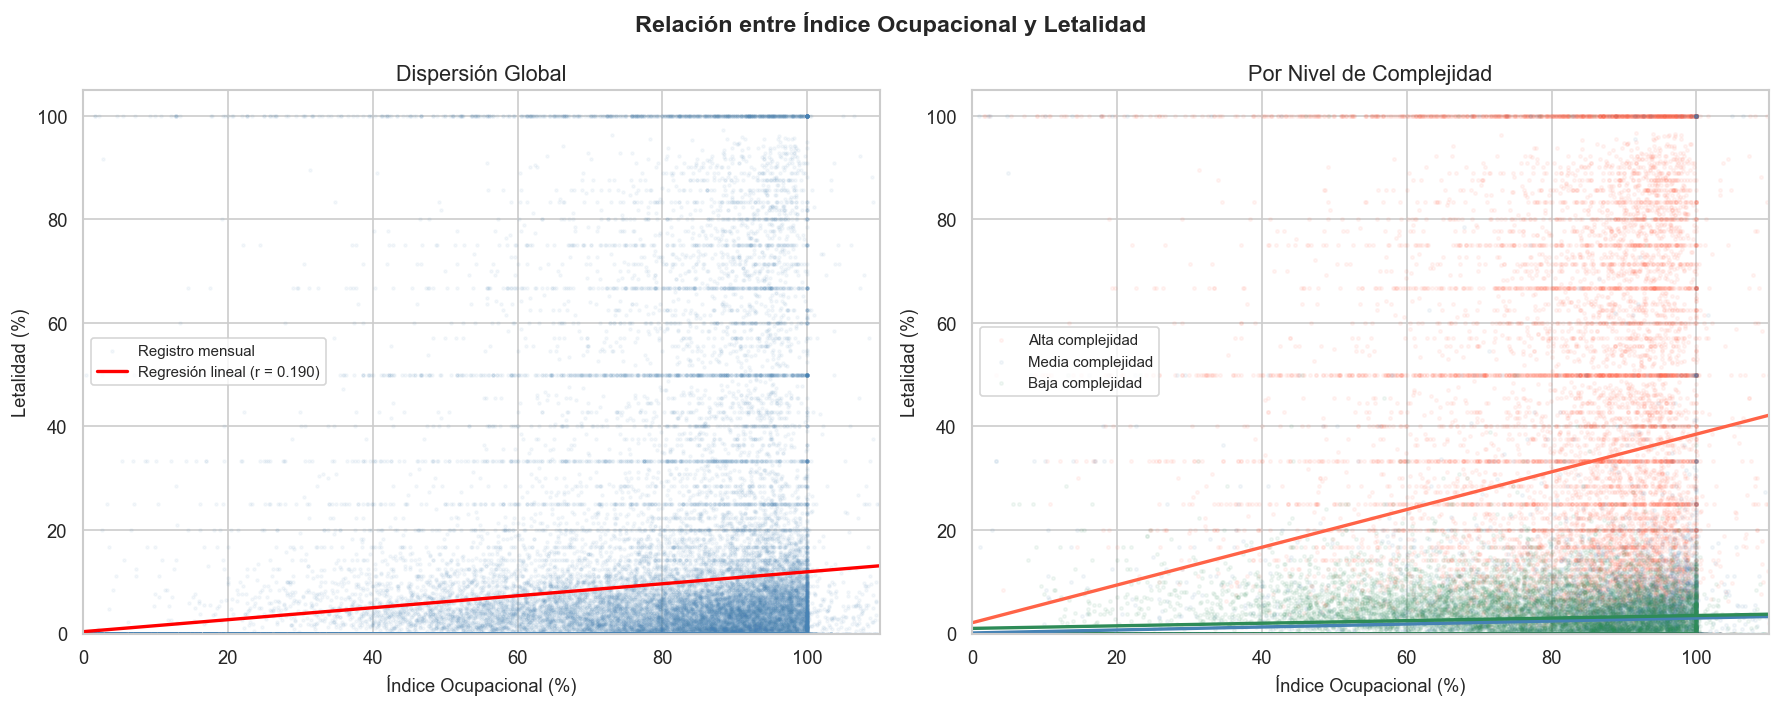

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Relación entre Índice Ocupacional y Letalidad', fontsize=14, fontweight='bold')

# --- Scatter general con regresión ---
ax = axes[0]
# Muestra aleatoria para no saturar el gráfico (100k puntos)
sample = df_p5.sample(min(50000, len(df_p5)), random_state=42)
ax.scatter(sample['INDICE_OCUPACIONAL'], sample['LETALIDAD'],
           alpha=0.05, s=3, color='steelblue', label='Registro mensual')

# Línea de regresión
m, b = np.polyfit(df_p5['INDICE_OCUPACIONAL'], df_p5['LETALIDAD'], 1)
x_line = np.linspace(df_p5['INDICE_OCUPACIONAL'].min(), df_p5['INDICE_OCUPACIONAL'].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Regresión lineal (r = {r_pearson:.3f})')

ax.set_xlabel('Índice Ocupacional (%)')
ax.set_ylabel('Letalidad (%)')
ax.set_title('Dispersión Global')
ax.legend(fontsize=9)
ax.set_xlim(0, 110)
ax.set_ylim(0, 105)

# --- Scatter por nivel de complejidad ---
ax = axes[1]
for comp in ['Alta complejidad', 'Media complejidad', 'Baja complejidad']:
    sub = df_p5[df_p5['COMPLEJIDAD'] == comp].sample(min(15000, len(df_p5[df_p5['COMPLEJIDAD'] == comp])), random_state=42)
    ax.scatter(sub['INDICE_OCUPACIONAL'], sub['LETALIDAD'],
               alpha=0.06, s=4, color=palette[comp], label=comp)
    # Tendencia por grupo
    m2, b2 = np.polyfit(df_p5[df_p5['COMPLEJIDAD'] == comp]['INDICE_OCUPACIONAL'],
                         df_p5[df_p5['COMPLEJIDAD'] == comp]['LETALIDAD'], 1)
    ax.plot(x_line, m2 * x_line + b2, color=palette[comp], linewidth=2)

ax.set_xlabel('Índice Ocupacional (%)')
ax.set_ylabel('Letalidad (%)')
ax.set_title('Por Nivel de Complejidad')
ax.legend(fontsize=9)
ax.set_xlim(0, 110)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

   Rango Ocupación  Letalidad Media  Letalidad Mediana  N registros
      0-50% (Baja)             2.11               0.00        39403
 50-70% (Moderada)             5.59               0.00        29289
     70-85% (Alta)             9.23               0.00        32062
85-100% (Muy alta)            13.60               2.63        49593
   >100% (Crítica)            10.57               1.50         1778


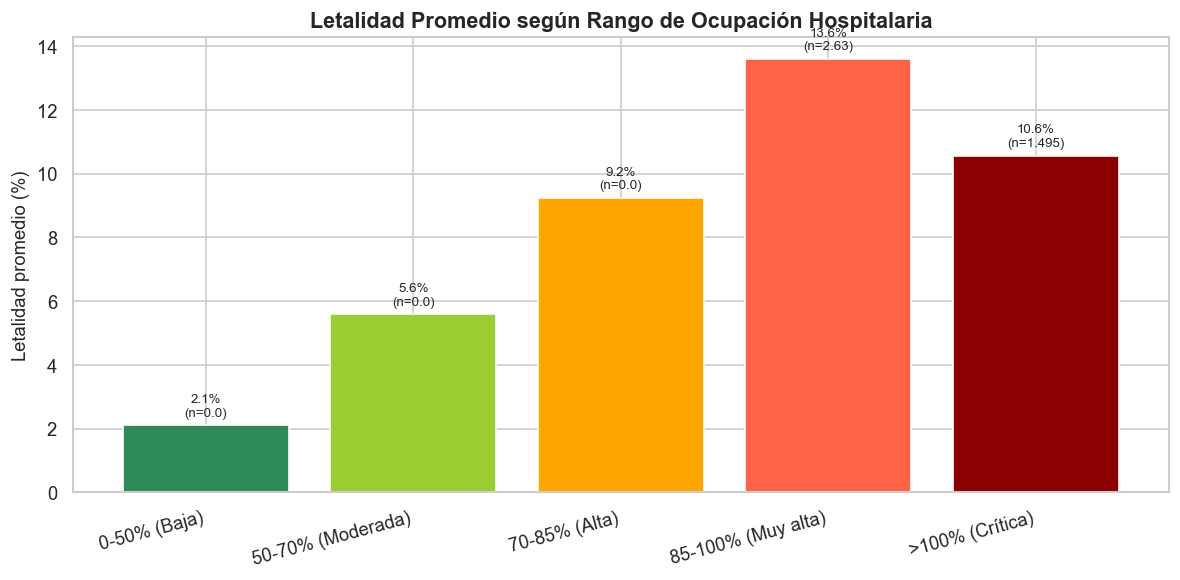

In [ ]:
# Análisis por rangos de ocupación: ¿sube la letalidad con alta saturación?
df_p5['RANGO_OCUPACION'] = pd.cut(
    df_p5['INDICE_OCUPACIONAL'],
    bins=[0, 50, 70, 85, 100, np.inf],
    labels=['0-50% (Baja)', '50-70% (Moderada)', '70-85% (Alta)', '85-100% (Muy alta)', '>100% (Crítica)']
)

p5_bins = df_p5.groupby('RANGO_OCUPACION', observed=True)['LETALIDAD'].agg(['mean', 'median', 'count']).reset_index()
p5_bins.columns = ['Rango Ocupación', 'Letalidad Media', 'Letalidad Mediana', 'N registros']
print(p5_bins.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(p5_bins))
bars = ax.bar(x, p5_bins['Letalidad Media'],
              color=['seagreen', 'yellowgreen', 'orange', 'tomato', 'darkred'],
              edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(p5_bins['Rango Ocupación'], rotation=15, ha='right')
ax.set_ylabel('Letalidad promedio (%)')
ax.set_title('Letalidad Promedio según Rango de Ocupación Hospitalaria', fontweight='bold')
for bar, row in zip(bars, p5_bins.itertuples()):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2,
            f'{h:.1f}%\n(n={row._3:,})', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

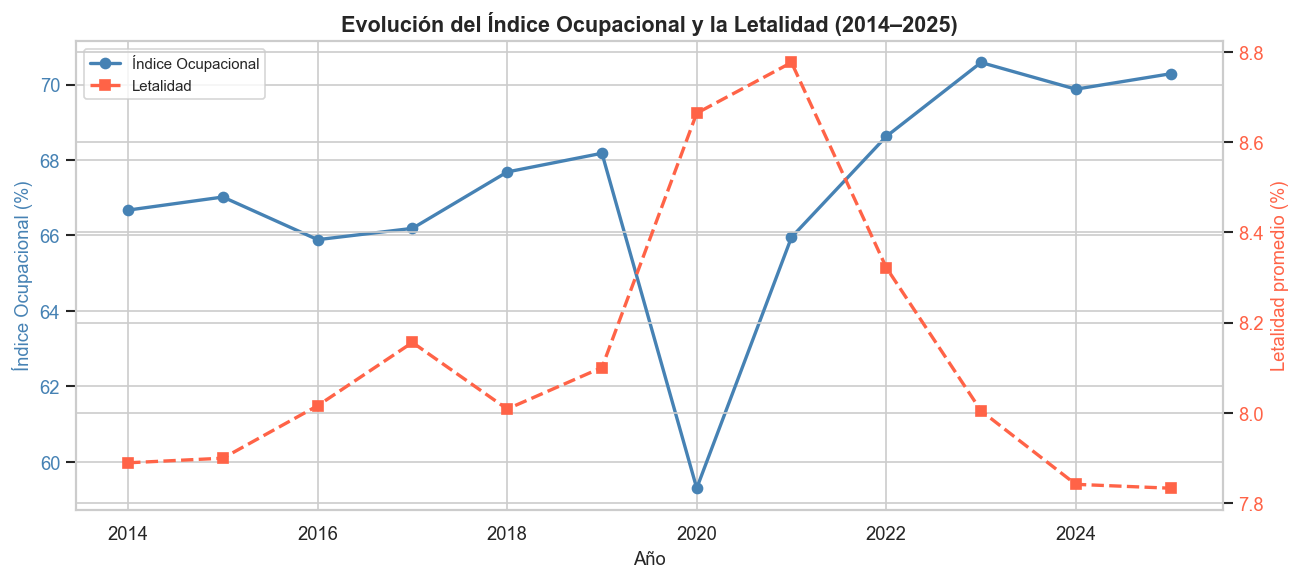

In [19]:
# Evolución temporal de la relación ocupación-letalidad
p5_anual = df_p5.groupby('PERIODO').agg(
    INDICE_OCUPACIONAL=('INDICE_OCUPACIONAL', 'mean'),
    LETALIDAD=('LETALIDAD', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(p5_anual['PERIODO'], p5_anual['INDICE_OCUPACIONAL'],
         marker='o', color='steelblue', linewidth=2, label='Índice Ocupacional')
ax2.plot(p5_anual['PERIODO'], p5_anual['LETALIDAD'],
         marker='s', color='tomato', linewidth=2, linestyle='--', label='Letalidad')

ax1.set_xlabel('Año')
ax1.set_ylabel('Índice Ocupacional (%)', color='steelblue')
ax2.set_ylabel('Letalidad promedio (%)', color='tomato')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Evolución del Índice Ocupacional y la Letalidad (2014–2025)', fontweight='bold')

plt.tight_layout()
plt.show()